# Notebook 07 — Executive Storytelling & Visual Insights

## Olist Customer Retention & Value Optimization

This notebook brings together the key findings from Notebooks 01–06
into a single visual business story.

Rather than introducing new analysis, this notebook focuses on:

- What did we learn about Olist customers?
- Where is customer value concentrated?
- Where are the biggest retention opportunities?
- When do incentives make economic sense?
- Which product categories deserve attention?
- Can machine learning improve customer prioritization?
- How should these insights translate into business action?

The objective is to transform six analytical notebooks into one
coherent, decision-oriented story.

In [2]:
# ============================================================
# CELL 2 — LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

print("Libraries imported successfully.")
print("Notebook 07: Executive Storytelling & Visual Insights")

Libraries imported successfully.
Notebook 07: Executive Storytelling & Visual Insights


In [3]:
# ============================================================
# CELL 3 — VISUALIZATION CONFIGURATION
# ============================================================

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

sns.set_theme(style="whitegrid")

print("Visualization configuration ready.")

Visualization configuration ready.


In [5]:
from pathlib import Path
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles/folders here:")
print(os.listdir())

Current working directory:
C:\Users\DELL\Desktop\checkout-incentives-ltv\notebooks

Files/folders here:
['.ipynb_checkpoints', '01_data_audit.ipynb', '02_ltv_modeling.ipynb', '03_checkout_incentive_analysis.ipynb', '04_repeat_purchase_prediction.ipynb', '05_product_category_analysis.ipynb', '06_customer_repeat_prediction.ipynb', 'catboost_info', 'story_book.ipynb']


In [6]:
from pathlib import Path

cwd = Path.cwd()

print("Current directory:", cwd)
print("\nParent directory:", cwd.parent)

print("\nParent contents:")
for item in cwd.parent.iterdir():
    print(item)

Current directory: C:\Users\DELL\Desktop\checkout-incentives-ltv\notebooks

Parent directory: C:\Users\DELL\Desktop\checkout-incentives-ltv

Parent contents:
C:\Users\DELL\Desktop\checkout-incentives-ltv\.git
C:\Users\DELL\Desktop\checkout-incentives-ltv\.gitignore
C:\Users\DELL\Desktop\checkout-incentives-ltv\.ipynb_checkpoints
C:\Users\DELL\Desktop\checkout-incentives-ltv\app
C:\Users\DELL\Desktop\checkout-incentives-ltv\data
C:\Users\DELL\Desktop\checkout-incentives-ltv\main.py
C:\Users\DELL\Desktop\checkout-incentives-ltv\models
C:\Users\DELL\Desktop\checkout-incentives-ltv\notebooks
C:\Users\DELL\Desktop\checkout-incentives-ltv\README.md
C:\Users\DELL\Desktop\checkout-incentives-ltv\reports
C:\Users\DELL\Desktop\checkout-incentives-ltv\requirements.txt
C:\Users\DELL\Desktop\checkout-incentives-ltv\src
C:\Users\DELL\Desktop\checkout-incentives-ltv\tests
C:\Users\DELL\Desktop\checkout-incentives-ltv\venv


In [7]:
from pathlib import Path

DATA_DIR = Path("../data")

print("Data directory:")
print(DATA_DIR.resolve())

print("\nFiles in data directory:")
for file in DATA_DIR.iterdir():
    print(file.name)

Data directory:
C:\Users\DELL\Desktop\checkout-incentives-ltv\data

Files in data directory:
interim
processed
raw


In [8]:
# ============================================================
# CELL 4A — INSPECT RAW DATA FILES
# ============================================================

RAW_DIR = Path("../data/raw")

print("Raw data directory:")
print(RAW_DIR.resolve())

print("\nFiles in raw data directory:")
for file in RAW_DIR.iterdir():
    print(file.name)

Raw data directory:
C:\Users\DELL\Desktop\checkout-incentives-ltv\data\raw

Files in raw data directory:
olist_customers_dataset.csv
olist_geolocation_dataset.csv
olist_orders_dataset.csv
olist_order_items_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_products_dataset.csv
olist_sellers_dataset.csv
product_category_name_translation.csv


In [9]:
# ============================================================
# CELL 4 — LOAD CORE DATASETS
# ============================================================

RAW_DIR = Path("../data/raw")

customers = pd.read_csv(RAW_DIR / "olist_customers_dataset.csv")
orders = pd.read_csv(RAW_DIR / "olist_orders_dataset.csv")
order_items = pd.read_csv(RAW_DIR / "olist_order_items_dataset.csv")
payments = pd.read_csv(RAW_DIR / "olist_order_payments_dataset.csv")
products = pd.read_csv(RAW_DIR / "olist_products_dataset.csv")
reviews = pd.read_csv(RAW_DIR / "olist_order_reviews_dataset.csv")
sellers = pd.read_csv(RAW_DIR / "olist_sellers_dataset.csv")
geolocation = pd.read_csv(RAW_DIR / "olist_geolocation_dataset.csv")
category_translation = pd.read_csv(
    RAW_DIR / "product_category_name_translation.csv"
)

print("Datasets loaded successfully.")
print("=" * 60)

print(f"Customers:              {customers.shape}")
print(f"Orders:                 {orders.shape}")
print(f"Order items:            {order_items.shape}")
print(f"Payments:               {payments.shape}")
print(f"Products:               {products.shape}")
print(f"Reviews:                {reviews.shape}")
print(f"Sellers:                {sellers.shape}")
print(f"Geolocation:            {geolocation.shape}")
print(f"Category translation:   {category_translation.shape}")

Datasets loaded successfully.
Customers:              (99441, 5)
Orders:                 (99441, 8)
Order items:            (112650, 7)
Payments:               (103886, 5)
Products:               (32951, 9)
Reviews:                (99224, 7)
Sellers:                (3095, 4)
Geolocation:            (1000163, 5)
Category translation:   (71, 2)


# 1. The Business Problem

Olist has a large customer base and substantial transaction activity,
but most customers do not make a second purchase within the observed
period.

This creates a fundamental retention question:

> **How can Olist identify valuable customers, understand repeat-purchase
> behavior, determine where retention incentives make economic sense,
> and prioritize customers for future retention campaigns?**

The project approaches this question progressively:

**Notebook 01 — Data Audit**  
Can the underlying data be trusted?

↓

**Notebook 02 — LTV Modeling**  
Who are the most valuable customers?

↓

**Notebook 03 — Checkout Incentive Analysis**  
What behavioral patterns and incentive opportunities exist?

↓

**Notebook 04 — High-Value Conversion & Incentive Economics**  
Where could incentives create financially attractive conversions?

↓

**Notebook 05 — Product Category Retention**  
Which product categories show stronger retention signals?

↓

**Notebook 06 — Customer Repeat-Purchase Prediction**  
Can we identify customers with higher repeat-purchase potential?

↓

**Notebook 07 — Executive Storytelling**  
What do all these findings mean for the business?

---

### The central business objective

The goal is not simply to maximize the number of repeat customers.

The goal is to:

> **Identify the customers and situations where retention efforts are
> most likely to create incremental business value, while avoiding
> unnecessary incentive spending.**

In [10]:
# ============================================================
# CELL 6 — EXECUTIVE SNAPSHOT
# ============================================================

# Established project-level figures from Notebooks 01–06
total_customers = 96096
repeat_customers = 2997
one_time_customers = total_customers - repeat_customers
repeat_rate = repeat_customers / total_customers * 100

print("=" * 70)
print("EXECUTIVE SNAPSHOT")
print("=" * 70)

print(f"Total customers:        {total_customers:,}")
print(f"One-time customers:     {one_time_customers:,}")
print(f"Repeat customers:       {repeat_customers:,}")
print(f"Repeat-purchase rate:   {repeat_rate:.2f}%")

EXECUTIVE SNAPSHOT
Total customers:        96,096
One-time customers:     93,099
Repeat customers:       2,997
Repeat-purchase rate:   3.12%


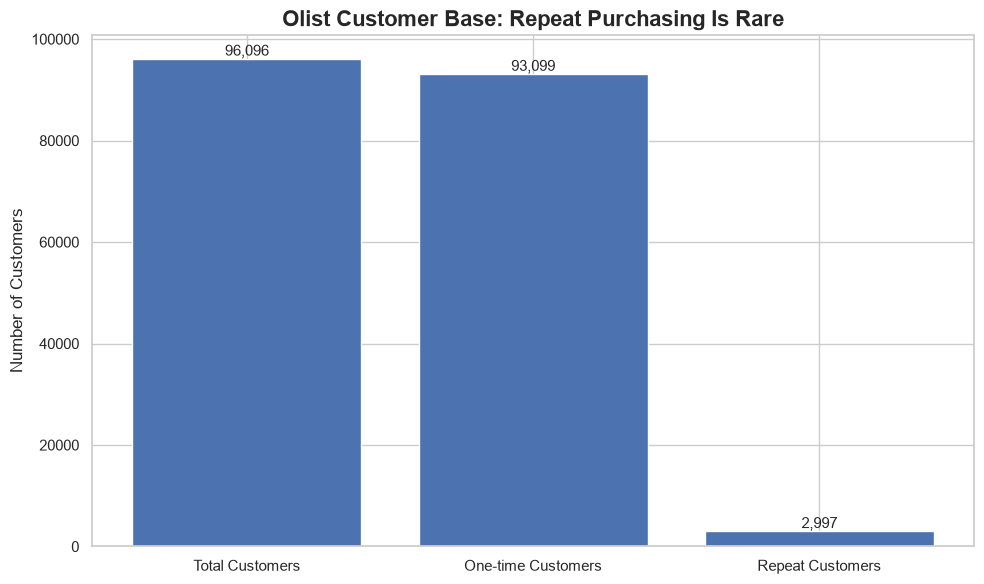

In [11]:
# ============================================================
# CELL 7 — EXECUTIVE SNAPSHOT VISUAL
# ============================================================

labels = [
    "Total Customers",
    "One-time Customers",
    "Repeat Customers"
]

values = [
    total_customers,
    one_time_customers,
    repeat_customers
]

plt.figure(figsize=(10, 6))

bars = plt.bar(labels, values)

plt.title(
    "Olist Customer Base: Repeat Purchasing Is Rare",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Number of Customers")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.show()

### What this tells us

The Olist customer base is dominated by one-time purchasers.

Approximately **97% of customers in the broad first-order population
do not appear as repeat purchasers**, while only a small minority
purchase again.

This makes customer retention a highly imbalanced business problem.

However, the low repeat rate alone does not tell us where the
opportunity lies.

A customer who purchases once for R$20 and a customer who purchases
once for R$2,000 are not economically equivalent.

Therefore, the next question is:

> **Are all customers equally valuable?**

The answer leads us to Customer Lifetime Value.

# 2. Customer Value: Not All Customers Are Equal

Retention should not be evaluated only by counting customers.

A more useful business perspective is to ask:

> **How much value does each customer generate over their observed
> relationship with Olist?**

Notebook 02 therefore used historical Customer Lifetime Value (LTV),
defined from the customer's observed total spending.

This allows the customer base to be viewed not only in terms of
frequency, but also in terms of economic value.

The analysis revealed strong skewness in customer value, with a
relatively small group of customers contributing substantially more
revenue than the typical customer.

In [12]:
# ============================================================
# CELL 10 — CUSTOMER-LEVEL HISTORICAL LTV
# ============================================================

# Merge order items with customer identity
order_items_ltv = (
    order_items
    .merge(
        orders[["order_id", "customer_id"]],
        on="order_id",
        how="left"
    )
    .merge(
        customers[["customer_id", "customer_unique_id"]],
        on="customer_id",
        how="left"
    )
)

# Customer-level historical spend
customer_ltv = (
    order_items_ltv
    .groupby("customer_unique_id", as_index=False)
    .agg(
        historical_ltv=("price", "sum"),
        total_items=("order_item_id", "count"),
        order_count=("order_id", "nunique")
    )
)

print("Customer-level LTV dataset created.")
print(f"Customers: {len(customer_ltv):,}")

print("\nLTV statistics:")
print(customer_ltv["historical_ltv"].describe())

Customer-level LTV dataset created.
Customers: 95,420

LTV statistics:
count    95420.000000
mean       142.440198
std        217.656355
min          0.850000
25%         47.900000
50%         89.900000
75%        155.000000
max      13440.000000
Name: historical_ltv, dtype: float64


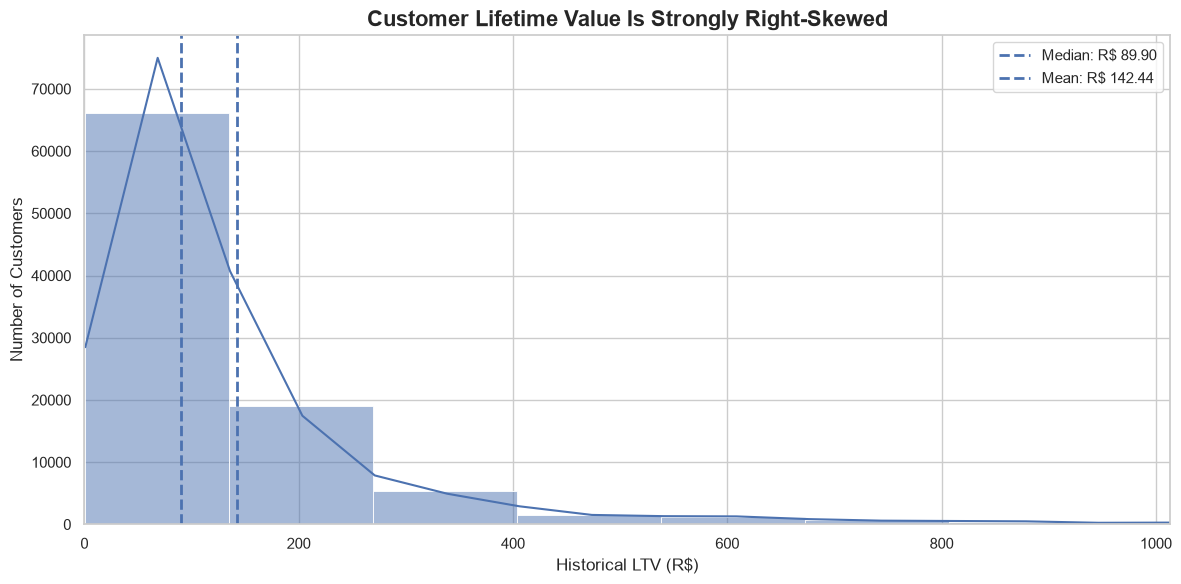

In [13]:
# ============================================================
# CELL 11 — LTV DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 6))

sns.histplot(
    customer_ltv["historical_ltv"],
    bins=100,
    kde=True
)

plt.axvline(
    customer_ltv["historical_ltv"].median(),
    linestyle="--",
    linewidth=2,
    label=f"Median: R$ {customer_ltv['historical_ltv'].median():,.2f}"
)

plt.axvline(
    customer_ltv["historical_ltv"].mean(),
    linestyle="--",
    linewidth=2,
    label=f"Mean: R$ {customer_ltv['historical_ltv'].mean():,.2f}"
)

plt.title(
    "Customer Lifetime Value Is Strongly Right-Skewed",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Historical LTV (R$)")
plt.ylabel("Number of Customers")

plt.xlim(0, customer_ltv["historical_ltv"].quantile(0.99))

plt.legend()
plt.tight_layout()
plt.show()

### What this tells us

Customer value is highly uneven.

The **median historical LTV is R$89.90**, while the mean is
**R$142.44**. The mean is therefore substantially higher than the
median because a smaller number of customers generate much larger
observed spend.

The maximum observed historical LTV reaches **R$13,440**, further
demonstrating the long right tail.

This has an important business implication:

> **A retention strategy that treats every customer identically is
> unlikely to allocate resources efficiently.**

A small improvement in retention among high-value customers can be
economically more important than the same improvement among low-value
customers.

This motivates customer-value segmentation and Pareto analysis.

In [14]:
# ============================================================
# CELL 13 — LTV BANDS
# ============================================================

bins = [0, 50, 100, 250, 500, 1000, 2000, np.inf]

labels = [
    "<50",
    "50–100",
    "100–250",
    "250–500",
    "500–1000",
    "1000–2000",
    "2000+"
]

customer_ltv["ltv_band"] = pd.cut(
    customer_ltv["historical_ltv"],
    bins=bins,
    labels=labels,
    right=False
)

ltv_bands = (
    customer_ltv["ltv_band"]
    .value_counts()
    .reindex(labels)
    .reset_index()
)

ltv_bands.columns = ["LTV Band", "Customers"]

ltv_bands["Customer %"] = (
    ltv_bands["Customers"] /
    ltv_bands["Customers"].sum() * 100
)

print("=" * 70)
print("LTV DISTRIBUTION")
print("=" * 70)

display(
    ltv_bands.style.format({
        "Customers": "{:,.0f}",
        "Customer %": "{:.2f}%"
    })
)

LTV DISTRIBUTION


,LTV Band,Customers,Customer %
0,<50,"27,585",28.91%
1,50–100,"26,949",28.24%
2,100–250,"29,541",30.96%
3,250–500,"7,568",7.93%
4,500–1000,"2,799",2.93%
5,1000–2000,826,0.87%
6,2000+,152,0.16%


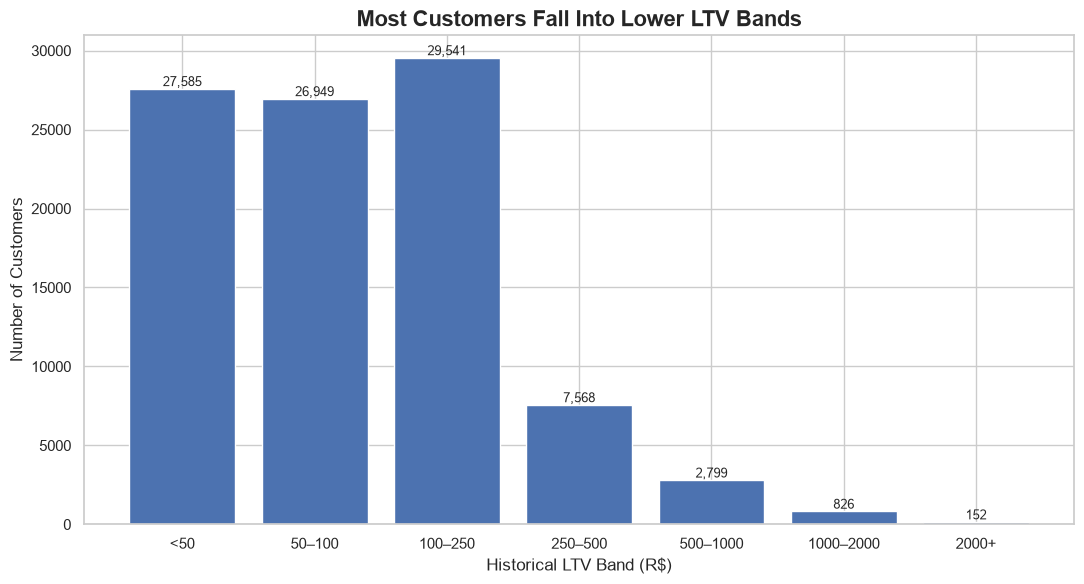

In [15]:
# ============================================================
# CELL 14 — LTV BAND VISUALIZATION
# ============================================================

plt.figure(figsize=(11, 6))

bars = plt.bar(
    ltv_bands["LTV Band"],
    ltv_bands["Customers"]
)

plt.title(
    "Most Customers Fall Into Lower LTV Bands",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Historical LTV Band (R$)")
plt.ylabel("Number of Customers")

for bar, value in zip(bars, ltv_bands["Customers"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

### What this tells us

The customer base is concentrated in the lower and middle LTV bands.

The largest segment falls between **R$100 and R$250**, while progressively
fewer customers appear in the highest-value bands.

This creates two different business opportunities:

1. **Large-scale retention opportunity**
   
   The lower and middle LTV groups contain a large number of customers,
   so even small improvements in repeat purchasing can generate
   meaningful aggregate revenue.

2. **High-value retention opportunity**
   
   The small group of customers with substantially higher LTV represents
   a more concentrated pool of customer value.

Therefore, the business should not use a single retention strategy for
the entire customer base.

> **Retention strategy should depend on both customer value and
> likelihood of future purchasing.**

In [16]:
# ============================================================
# CELL 16 — LTV REVENUE CONCENTRATION / PARETO ANALYSIS
# ============================================================

pareto_ltv = customer_ltv.sort_values(
    "historical_ltv",
    ascending=False
).reset_index(drop=True)

pareto_ltv["cumulative_revenue"] = (
    pareto_ltv["historical_ltv"].cumsum()
)

total_ltv = pareto_ltv["historical_ltv"].sum()

pareto_ltv["cumulative_revenue_pct"] = (
    pareto_ltv["cumulative_revenue"] /
    total_ltv * 100
)

pareto_ltv["customer_pct"] = (
    (np.arange(len(pareto_ltv)) + 1) /
    len(pareto_ltv) * 100
)

# Revenue captured by top 10%
top_10_index = int(len(pareto_ltv) * 0.10)

top_10_revenue_pct = (
    pareto_ltv.iloc[top_10_index - 1]["cumulative_revenue_pct"]
)

print("=" * 70)
print("PARETO / REVENUE CONCENTRATION")
print("=" * 70)

print(
    f"Top 10% of customers account for approximately "
    f"{top_10_revenue_pct:.2f}% of observed customer revenue."
)

PARETO / REVENUE CONCENTRATION
Top 10% of customers account for approximately 41.23% of observed customer revenue.


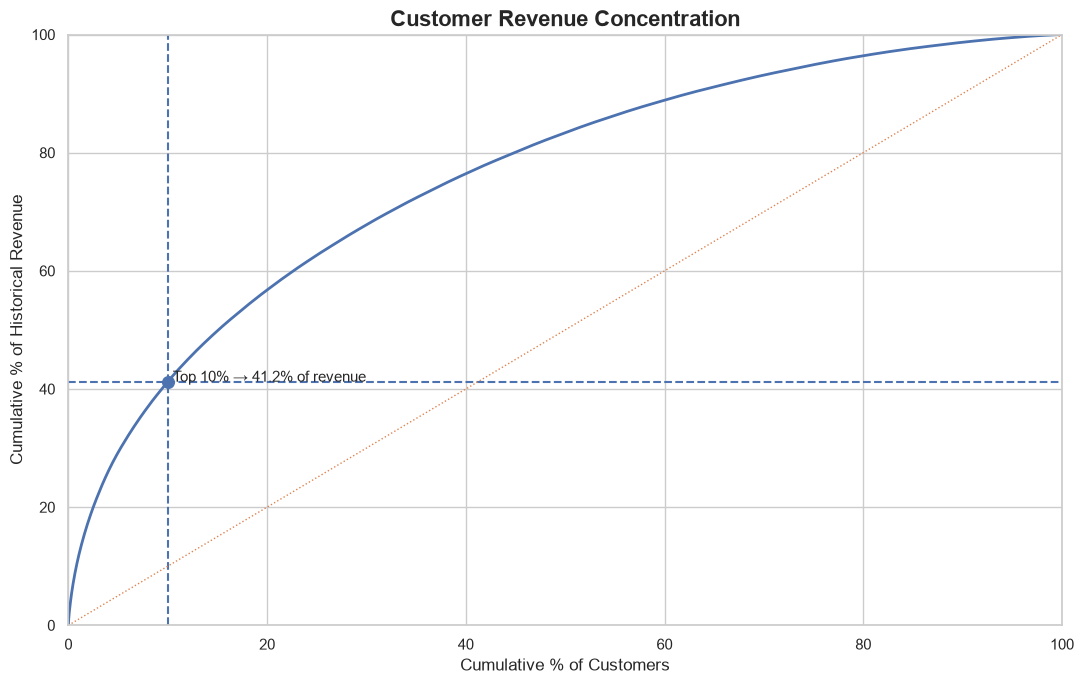

In [17]:
# ============================================================
# CELL 17 — PARETO CURVE
# ============================================================

plt.figure(figsize=(11, 7))

plt.plot(
    pareto_ltv["customer_pct"],
    pareto_ltv["cumulative_revenue_pct"],
    linewidth=2
)

plt.axvline(
    10,
    linestyle="--",
    linewidth=1.5
)

plt.axhline(
    top_10_revenue_pct,
    linestyle="--",
    linewidth=1.5
)

plt.scatter(
    [10],
    [top_10_revenue_pct],
    s=70
)

plt.text(
    10.5,
    top_10_revenue_pct,
    f"Top 10% → {top_10_revenue_pct:.1f}% of revenue",
    fontsize=11
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle=":",
    linewidth=1
)

plt.title(
    "Customer Revenue Concentration",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Cumulative % of Customers")
plt.ylabel("Cumulative % of Historical Revenue")

plt.xlim(0, 100)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

### What this tells us

The Pareto curve shows that customer revenue is not distributed evenly
across the customer base.

Higher-value customers contribute disproportionately more observed
revenue.

This reinforces an important product principle:

> **Customer retention should be value-aware.**

A blanket incentive offered to every customer could waste budget on
customers who generate little incremental value.

Instead, the business can consider:

- higher-touch retention for high-value customers,
- lower-cost interventions for lower-value customers,
- and selective incentives where the expected incremental value
  justifies the incentive cost.

However, historical LTV is **descriptive rather than predictive**.

A high historical LTV customer is valuable based on what they have
already purchased, but this does not automatically mean they will
purchase again.

That distinction leads to the next question:

> **Which customers actually demonstrate repeat-purchase behavior?**

In [18]:
# ============================================================
# CELL 19 — CUSTOMER PURCHASE FREQUENCY
# ============================================================

customer_orders = (
    orders
    .merge(
        customers[["customer_id", "customer_unique_id"]],
        on="customer_id",
        how="left"
    )
    .groupby("customer_unique_id", as_index=False)
    .agg(
        order_count=("order_id", "nunique")
    )
)

customer_orders["customer_type"] = np.where(
    customer_orders["order_count"] >= 2,
    "Repeat",
    "One-time"
)

purchase_type_summary = (
    customer_orders["customer_type"]
    .value_counts()
    .rename_axis("Customer Type")
    .reset_index(name="Customers")
)

purchase_type_summary["Percentage"] = (
    purchase_type_summary["Customers"] /
    purchase_type_summary["Customers"].sum() * 100
)

print("=" * 70)
print("CUSTOMER PURCHASE FREQUENCY")
print("=" * 70)

display(
    purchase_type_summary.style.format({
        "Customers": "{:,.0f}",
        "Percentage": "{:.2f}%"
    })
)

CUSTOMER PURCHASE FREQUENCY


,Customer Type,Customers,Percentage
0,One-time,"93,099",96.88%
1,Repeat,"2,997",3.12%


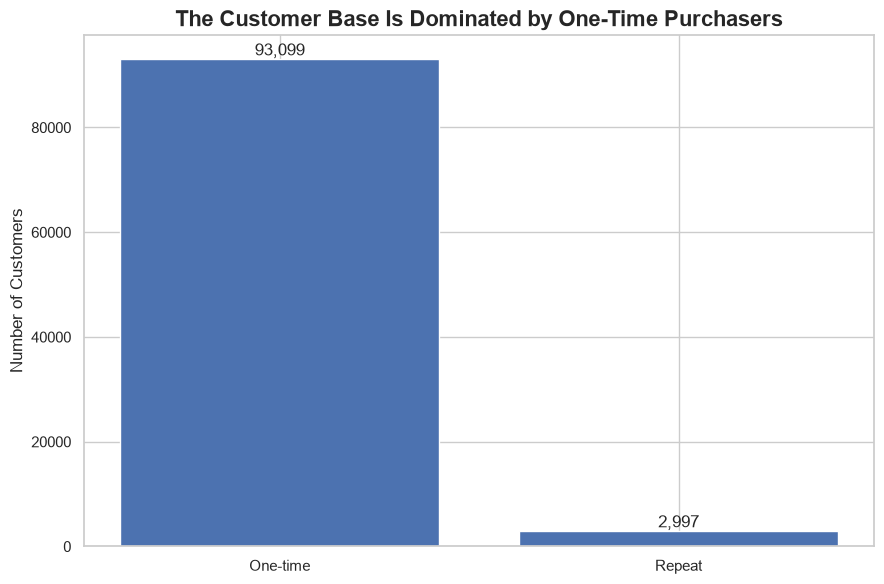

In [19]:
# ============================================================
# CELL 20 — ONE-TIME VS REPEAT CUSTOMERS
# ============================================================

plt.figure(figsize=(9, 6))

bars = plt.bar(
    purchase_type_summary["Customer Type"],
    purchase_type_summary["Customers"]
)

plt.title(
    "The Customer Base Is Dominated by One-Time Purchasers",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Number of Customers")

for bar, value in zip(
    bars,
    purchase_type_summary["Customers"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# CELL 21 — LTV × PURCHASE BEHAVIOR
# ============================================================

# Keep the LTV order count as the customer-level purchase frequency
customer_profile = customer_ltv.merge(
    customer_orders[["customer_unique_id", "customer_type"]],
    on="customer_unique_id",
    how="inner"
)

ltv_by_customer_type = (
    customer_profile
    .groupby("customer_type")
    .agg(
        customers=("customer_unique_id", "count"),
        mean_ltv=("historical_ltv", "mean"),
        median_ltv=("historical_ltv", "median"),
        mean_orders=("order_count", "mean")
    )
    .reset_index()
)

print("=" * 70)
print("LTV BY CUSTOMER TYPE")
print("=" * 70)

display(
    ltv_by_customer_type.style.format({
        "customers": "{:,.0f}",
        "mean_ltv": "R$ {:,.2f}",
        "median_ltv": "R$ {:,.2f}",
        "mean_orders": "{:.2f}"
    })
)

LTV BY CUSTOMER TYPE


,customer_type,customers,mean_ltv,median_ltv,mean_orders
0,One-time,"92,431",R$ 138.62,R$ 87.00,1.00
1,Repeat,"2,989",R$ 260.56,R$ 179.90,2.09


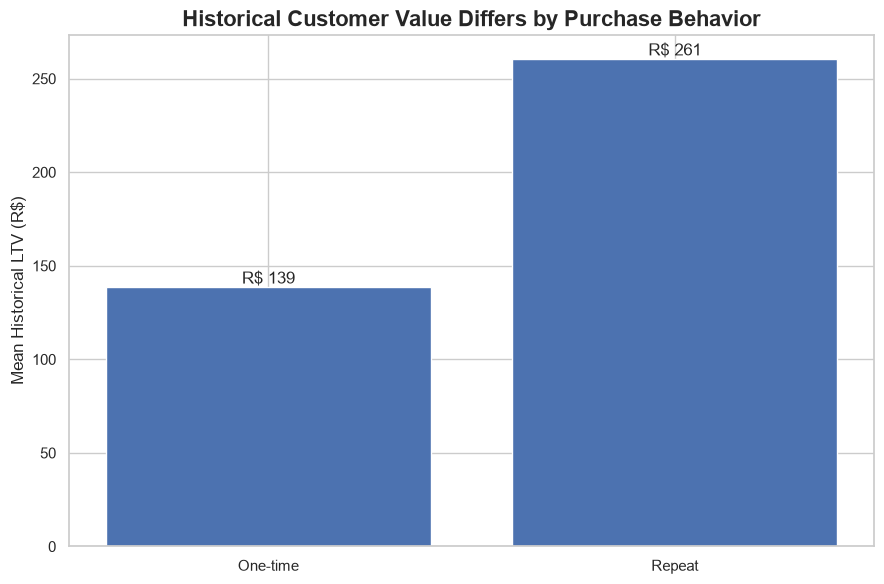

In [22]:
# ============================================================
# CELL 22 — LTV BY CUSTOMER TYPE
# ============================================================

plt.figure(figsize=(9, 6))

bars = plt.bar(
    ltv_by_customer_type["customer_type"],
    ltv_by_customer_type["mean_ltv"]
)

plt.title(
    "Historical Customer Value Differs by Purchase Behavior",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Mean Historical LTV (R$)")

for bar, value in zip(
    bars,
    ltv_by_customer_type["mean_ltv"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"R$ {value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### What this tells us

Purchase frequency and customer value are closely related, but they
represent different dimensions of customer behavior.

Repeat customers have generated multiple transactions, so their
historical LTV naturally tends to be higher.

However, this creates an especially interesting segment:

> **High-value customers who have purchased only once.**

These customers have already demonstrated meaningful economic value,
but have not yet established repeat behavior.

They therefore represent a potentially attractive retention opportunity.

This leads to a more useful segmentation framework:

| | Low Historical Value | High Historical Value |
|---|---|---|
| **One-time** | Low-priority / low-cost retention | **High-value conversion opportunity** |
| **Repeat** | Maintain efficiently | **Protect / retain aggressively** |

The important distinction is that these are **descriptive segments**.
They identify where the opportunity appears to exist historically;
they do not prove that an incentive will cause another purchase.

That question requires experimentation.

# 3. From Customer Value to Retention Action

The analysis so far establishes two important facts:

1. Repeat purchasing is relatively rare.
2. Customer value is highly uneven.

This creates a potential retention opportunity, but an incentive is
not automatically a good business decision.

A discount has a cost.

Therefore, the relevant question is not:

> "Can we increase repeat purchases?"

but:

> **"Can we increase repeat purchases enough to generate incremental
> value greater than the cost of the incentive?"**

Notebook 03 and Notebook 04 therefore moved from behavioral analysis
to incentive economics.

The analysis focused particularly on **high-value one-time customers**,
because they combine:

- demonstrated economic value,
- lack of repeat behavior,
- and therefore potential upside from conversion.

In [23]:
# ============================================================
# CELL 25 — HIGH-VALUE ONE-TIME SEGMENT
# ============================================================

# High-value threshold used for the storytelling segmentation
HIGH_VALUE_THRESHOLD = 250

high_value_one_time = customer_profile[
    (customer_profile["customer_type"] == "One-time") &
    (customer_profile["historical_ltv"] >= HIGH_VALUE_THRESHOLD)
].copy()

high_value_repeat = customer_profile[
    (customer_profile["customer_type"] == "Repeat") &
    (customer_profile["historical_ltv"] >= HIGH_VALUE_THRESHOLD)
].copy()

low_value_one_time = customer_profile[
    (customer_profile["customer_type"] == "One-time") &
    (customer_profile["historical_ltv"] < HIGH_VALUE_THRESHOLD)
].copy()

low_value_repeat = customer_profile[
    (customer_profile["customer_type"] == "Repeat") &
    (customer_profile["historical_ltv"] < HIGH_VALUE_THRESHOLD)
].copy()

print("=" * 70)
print("CUSTOMER VALUE × RETENTION SEGMENTS")
print("=" * 70)

print(f"High-value one-time : {len(high_value_one_time):,}")
print(f"High-value repeat   : {len(high_value_repeat):,}")
print(f"Low-value one-time  : {len(low_value_one_time):,}")
print(f"Low-value repeat    : {len(low_value_repeat):,}")

CUSTOMER VALUE × RETENTION SEGMENTS
High-value one-time : 10,334
High-value repeat   : 1,011
Low-value one-time  : 82,097
Low-value repeat    : 1,978


In [24]:
# ============================================================
# CELL 26 — FOUR-QUADRANT CUSTOMER SEGMENTATION
# ============================================================

segment_summary = pd.DataFrame({
    "Segment": [
        "High-value / One-time",
        "High-value / Repeat",
        "Low-value / One-time",
        "Low-value / Repeat"
    ],
    "Customers": [
        len(high_value_one_time),
        len(high_value_repeat),
        len(low_value_one_time),
        len(low_value_repeat)
    ]
})

segment_summary["Customer %"] = (
    segment_summary["Customers"] /
    segment_summary["Customers"].sum() * 100
)

display(
    segment_summary.style.format({
        "Customers": "{:,.0f}",
        "Customer %": "{:.2f}%"
    })
)

,Segment,Customers,Customer %
0,High-value / One-time,"10,334",10.83%
1,High-value / Repeat,"1,011",1.06%
2,Low-value / One-time,"82,097",86.04%
3,Low-value / Repeat,"1,978",2.07%


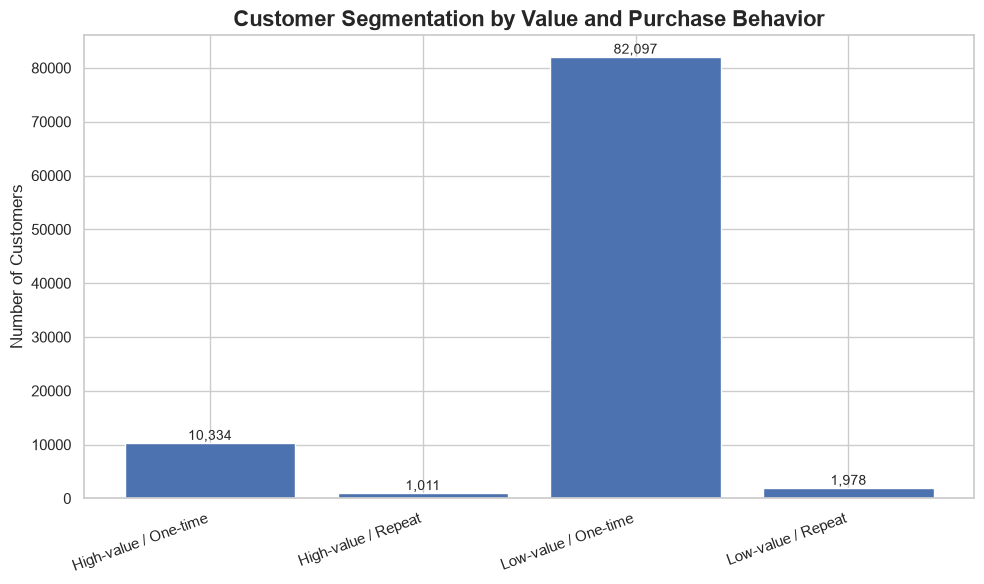

In [25]:
# ============================================================
# CELL 27 — FOUR-QUADRANT VISUAL
# ============================================================

plt.figure(figsize=(10, 6))

bars = plt.bar(
    segment_summary["Segment"],
    segment_summary["Customers"]
)

plt.title(
    "Customer Segmentation by Value and Purchase Behavior",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Number of Customers")
plt.xticks(rotation=20, ha="right")

for bar, value in zip(
    bars,
    segment_summary["Customers"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### The strategic segments

The four segments have fundamentally different business roles.

**High-value / Repeat**

These customers have already demonstrated both economic value and
repeat behavior.

**Recommended action:** protect and retain.

These customers may justify higher-touch retention strategies because
losing an established high-value customer can have a meaningful
economic impact.

---

**High-value / One-time**

These customers have generated meaningful historical value but have
not yet returned.

**Recommended action:** conversion opportunity.

This is the most interesting segment for carefully designed
retention incentives.

---

**Low-value / Repeat**

These customers have demonstrated repeat behavior, but their observed
value is relatively low.

**Recommended action:** maintain efficiently.

The objective should be retention without excessive incentive cost.

---

**Low-value / One-time**

These customers have neither demonstrated high historical value nor
repeat behavior.

**Recommended action:** low-cost or automated retention.

A costly incentive may not generate sufficient incremental value.

---

The key principle is therefore:

> **Retention budget should be allocated according to both customer
> value and retention opportunity.**

In [26]:
# ============================================================
# CELL 29 — INCENTIVE ECONOMICS SCENARIO MODEL
# ============================================================

# Use the high-value one-time population
target_customers = len(high_value_one_time)

# Estimated second-order value
average_second_order_value = high_value_one_time["historical_ltv"].mean()

# Scenario assumptions
conversion_rates = [0.01, 0.03, 0.05, 0.10]
incentive_costs = [5, 10, 15, 25]

scenarios = []

for conversion_rate in conversion_rates:
    converted_customers = target_customers * conversion_rate

    for incentive_cost in incentive_costs:

        incremental_revenue = (
            converted_customers *
            average_second_order_value
        )

        incentive_spend = (
            converted_customers *
            incentive_cost
        )

        incremental_profit_before_other_costs = (
            incremental_revenue -
            incentive_spend
        )

        roi = (
            incremental_profit_before_other_costs /
            incentive_spend
            if incentive_spend > 0
            else np.nan
        )

        scenarios.append({
            "conversion_rate": conversion_rate,
            "incentive_cost": incentive_cost,
            "converted_customers": converted_customers,
            "incremental_revenue": incremental_revenue,
            "incentive_spend": incentive_spend,
            "ROI": roi
        })

incentive_scenarios = pd.DataFrame(scenarios)

print("=" * 70)
print("INCENTIVE ECONOMICS SCENARIOS")
print("=" * 70)

display(
    incentive_scenarios.style.format({
        "conversion_rate": "{:.0%}",
        "incentive_cost": "R$ {:.2f}",
        "converted_customers": "{:,.0f}",
        "incremental_revenue": "R$ {:,.2f}",
        "incentive_spend": "R$ {:,.2f}",
        "ROI": "{:.2f}x"
    })
)

INCENTIVE ECONOMICS SCENARIOS


,conversion_rate,incentive_cost,converted_customers,incremental_revenue,incentive_spend,ROI
0,1%,R$ 5.00,103,"R$ 55,710.12",R$ 516.70,106.82x
1,1%,R$ 10.00,103,"R$ 55,710.12","R$ 1,033.40",52.91x
2,1%,R$ 15.00,103,"R$ 55,710.12","R$ 1,550.10",34.94x
3,1%,R$ 25.00,103,"R$ 55,710.12","R$ 2,583.50",20.56x
4,3%,R$ 5.00,310,"R$ 167,130.37","R$ 1,550.10",106.82x
5,3%,R$ 10.00,310,"R$ 167,130.37","R$ 3,100.20",52.91x
6,3%,R$ 15.00,310,"R$ 167,130.37","R$ 4,650.30",34.94x
7,3%,R$ 25.00,310,"R$ 167,130.37","R$ 7,750.50",20.56x
8,5%,R$ 5.00,517,"R$ 278,550.61","R$ 2,583.50",106.82x
9,5%,R$ 10.00,517,"R$ 278,550.61","R$ 5,167.00",52.91x


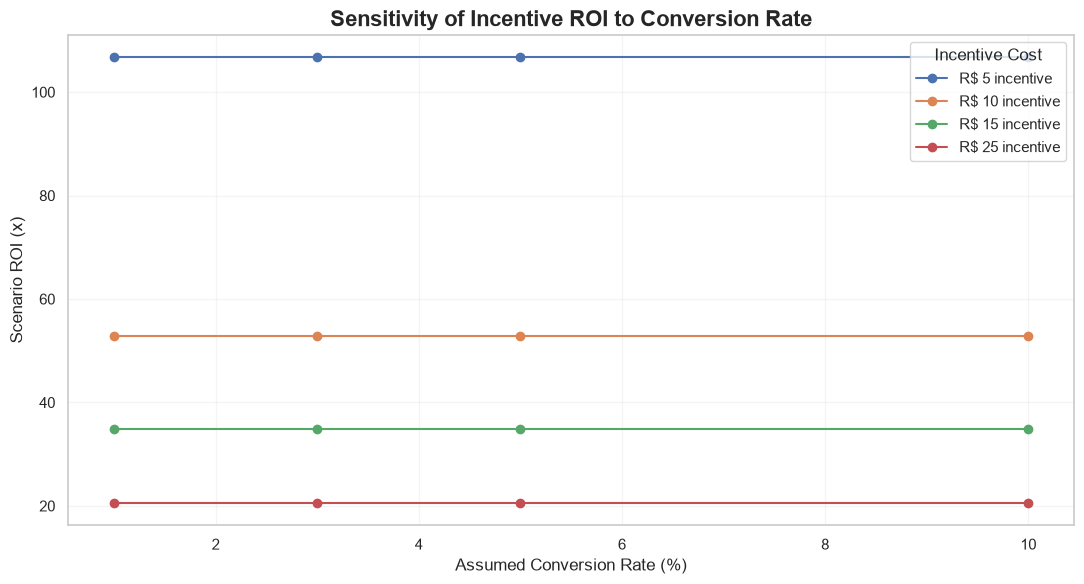

In [29]:
# ============================================================
# CELL 30 — INCENTIVE ECONOMICS SCENARIO VISUAL
# ============================================================

plt.figure(figsize=(11, 6))

for incentive_cost in incentive_costs:
    subset = incentive_scenarios[
        incentive_scenarios["incentive_cost"] == incentive_cost
    ]

    plt.plot(
        subset["conversion_rate"] * 100,
        subset["ROI"],
        marker="o",
        label=f"R$ {incentive_cost} incentive"
    )

plt.title(
    "Sensitivity of Incentive ROI to Conversion Rate",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Assumed Conversion Rate (%)")
plt.ylabel("Scenario ROI (x)")

plt.legend(title="Incentive Cost")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

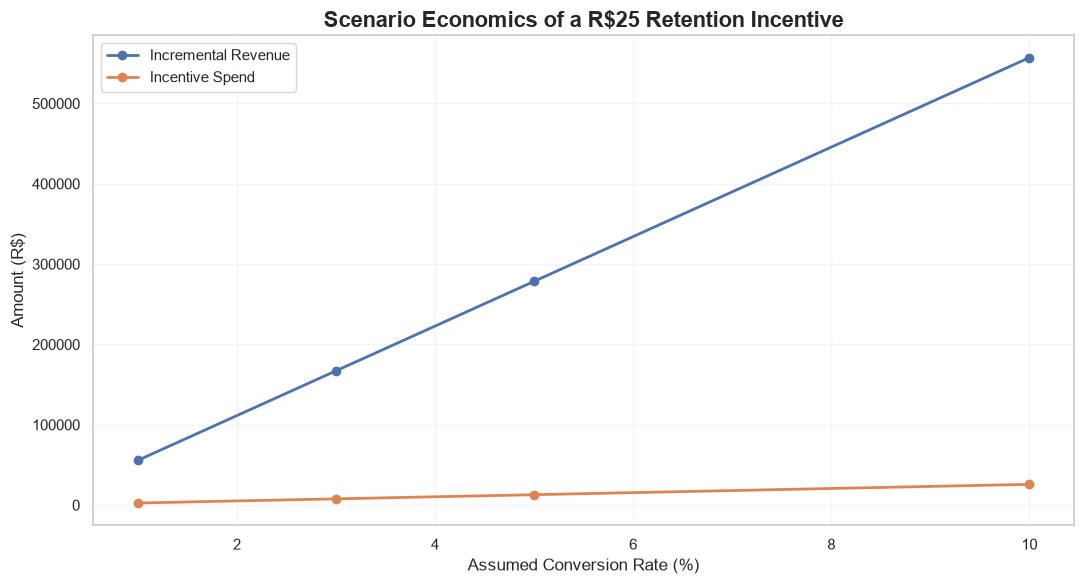

In [30]:
# ============================================================
# CELL 30 — INCENTIVE ECONOMICS: REVENUE VS COST
# ============================================================

plot_data = incentive_scenarios[
    incentive_scenarios["incentive_cost"] == 25
].copy()

plt.figure(figsize=(11, 6))

plt.plot(
    plot_data["conversion_rate"] * 100,
    plot_data["incremental_revenue"],
    marker="o",
    linewidth=2,
    label="Incremental Revenue"
)

plt.plot(
    plot_data["conversion_rate"] * 100,
    plot_data["incentive_spend"],
    marker="o",
    linewidth=2,
    label="Incentive Spend"
)

plt.title(
    "Scenario Economics of a R$25 Retention Incentive",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Assumed Conversion Rate (%)")
plt.ylabel("Amount (R$)")

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Important: Scenario Economics, Not Causal Evidence

The incentive analysis demonstrates how retention economics could change
under different assumptions.

For example, under the current scenario assumptions:

- 1% conversion → approximately 103 converted customers
- 5% conversion → approximately 517 converted customers
- 10% conversion → approximately 1,033 converted customers

At a R$25 incentive, the corresponding incentive expenditure would be
approximately:

- R$2,583 at 1% conversion
- R$12,918 at 5% conversion
- R$25,835 at 10% conversion

However, these figures should **not** be interpreted as predicted
conversion or guaranteed ROI.

The model assumes that converted customers generate the estimated
second-order value and that the incremental revenue is attributable to
the incentive.

Historical observational data cannot establish that causal relationship.

Therefore:

> **Scenario analysis tells us whether an incentive could be
> economically attractive; experimentation tells us whether it
> actually is.**


# 4. Validate the Strategy: A/B Testing

The incentive scenarios provide an economic hypothesis, but they do not prove that the incentive *causes* additional purchases. This is a causal question — a randomized A/B test is therefore required.

## Experimental Design

Eligible high-value one-time customers are randomly divided into two groups.

### Control
- No retention incentive
- Normal customer experience

### Treatment
- Receives the proposed retention incentive
- Example: R$25 incentive

The primary outcome is whether the customer makes another purchase within the predefined observation window.

## Primary Hypothesis

- **H₀:** The incentive does not change repeat-purchase conversion.
- **H₁:** The incentive increases repeat-purchase conversion.

## Primary Metric

```
Repeat Conversion = Customers making a second purchase / Eligible customers
```

## Incremental Conversion Lift

```
Incremental Lift = Conversion(Treatment) − Conversion(Control)
```

For example, if:
- Control = 3.0%
- Treatment = 5.0%

then:

```
Incremental Lift = 5.0% − 3.0% = 2.0 percentage points
```

This means the treatment generated **2 additional repeat customers per 100 eligible customers** compared with the control group.

> The treatment effect should be evaluated for both **statistical significance** and **business significance**.

## Secondary Business Metrics

- Incremental repeat purchases
- Incremental revenue
- Incentive cost
- Incremental profit
- ROI
- Average second-order value
- Time to second purchase

## Business Decision

A campaign should be considered successful only when:

1. Treatment conversion is statistically higher than control.
2. The incremental effect is commercially meaningful.
3. Incremental revenue justifies incentive and campaign costs.
4. The result is robust enough to support deployment.

Therefore, A/B testing converts the project's observational and scenario-based recommendations into **causally validated business decisions**.


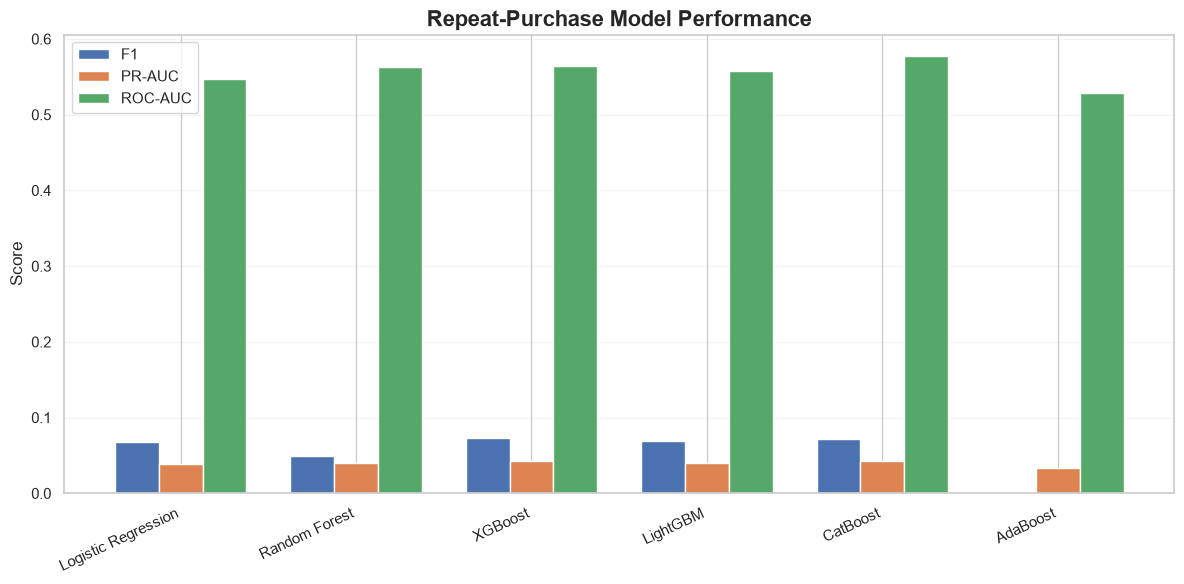

In [33]:
# ============================================================
# CELL 33 — ML MODEL PERFORMANCE COMPARISON
# ============================================================

model_metrics = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "CatBoost",
        "AdaBoost"
    ],
    "F1": [
        0.0677,
        0.0495,
        0.0734,
        0.0694,
        0.0711,
        0.0000
    ],
    "PR_AUC": [
        0.0390,
        0.0397,
        0.0424,
        0.0401,
        0.0432,
        0.0332
    ],
    "ROC_AUC": [
        0.5475,
        0.5631,
        0.5643,
        0.5571,
        0.5770,
        0.5282
    ]
})

x = np.arange(len(model_metrics))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(
    x - width,
    model_metrics["F1"],
    width,
    label="F1"
)

plt.bar(
    x,
    model_metrics["PR_AUC"],
    width,
    label="PR-AUC"
)

plt.bar(
    x + width,
    model_metrics["ROC_AUC"],
    width,
    label="ROC-AUC"
)

plt.xticks(
    x,
    model_metrics["Model"],
    rotation=25,
    ha="right"
)

plt.ylabel("Score")
plt.title(
    "Repeat-Purchase Model Performance",
    fontsize=16,
    fontweight="bold"
)

plt.legend()
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

## Why Accuracy Is Not the Decision Metric

The test set contains:

- **18,651 customers**
- **575 repeat customers**
- **18,076 one-time customers**
- Repeat rate = **3.08%**

Because the repeat class is rare, a model can achieve very high accuracy
simply by predicting almost everyone as one-time.

This is demonstrated by AdaBoost:

| Metric | AdaBoost |
|---|---:|
| Accuracy | **96.92%** |
| Precision | **0.00%** |
| Recall | **0.00%** |
| F1 | **0.00** |
| PR-AUC | **0.0332** |

Its confusion matrix shows:

- 18,076 one-time customers correctly classified
- **575 repeat customers completely missed**

Therefore, the 96.92% accuracy does not represent useful retention
prediction.

The project therefore prioritizes:

1. **PR-AUC** — performance on the rare repeat class
2. **F1-score** — balance between precision and recall
3. **Recall** — ability to identify repeat customers
4. **Top-K capture rate** — how many repeat customers can be reached
   when only a limited percentage of customers can be targeted
5. **Lift** — improvement over random targeting

This changes the business question from:

> "How accurately can we classify every customer?"

to:

> **"Can we rank customers well enough to prioritize retention
> campaigns?"**

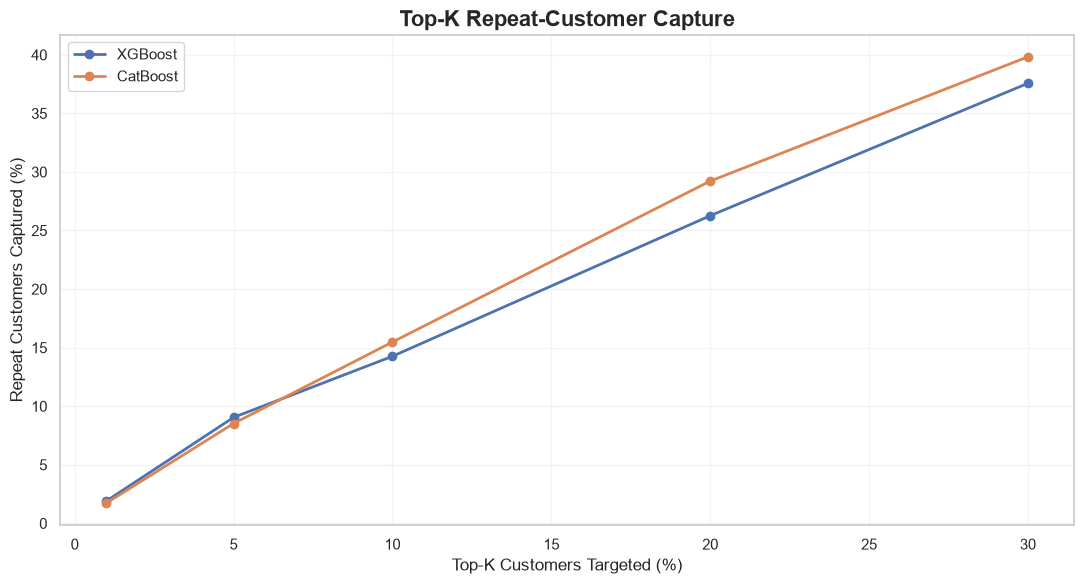

In [34]:
# ============================================================
# CELL 35 — TOP-K TARGETING PERFORMANCE
# ============================================================

top_k_results = pd.DataFrame({
    "Model": [
        "XGBoost", "XGBoost", "XGBoost", "XGBoost", "XGBoost",
        "CatBoost", "CatBoost", "CatBoost", "CatBoost", "CatBoost"
    ],
    "Top_K": [
        1, 5, 10, 20, 30,
        1, 5, 10, 20, 30
    ],
    "Capture_Rate": [
        1.913, 9.043, 14.261, 26.261, 37.565,
        1.739, 8.522, 15.478, 29.217, 39.826
    ],
    "Lift": [
        1.918, 1.810, 1.426, 1.313, 1.252,
        1.744, 1.705, 1.548, 1.461, 1.328
    ]
})

plt.figure(figsize=(11, 6))

for model in ["XGBoost", "CatBoost"]:
    subset = top_k_results[
        top_k_results["Model"] == model
    ]

    plt.plot(
        subset["Top_K"],
        subset["Capture_Rate"],
        marker="o",
        linewidth=2,
        label=model
    )

plt.xlabel("Top-K Customers Targeted (%)")
plt.ylabel("Repeat Customers Captured (%)")

plt.title(
    "Top-K Repeat-Customer Capture",
    fontsize=16,
    fontweight="bold"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## The Most Important ML Result: Top-K Targeting

The intended business use of the model is not to classify every customer with certainty. Instead, customers can be ranked by predicted repeat-purchase propensity, allowing the business to target only the highest-ranked customers.

At the **Top 10%**:

### XGBoost
- Customers targeted: **1,865**
- Repeat customers captured: **82**
- Capture rate: **14.26%**
- Lift: **1.426×**

### CatBoost
- Customers targeted: **1,865**
- Repeat customers captured: **89**
- Capture rate: **15.48%**
- Lift: **1.548×**

A random Top-10% selection would be expected to capture approximately 10% of repeat customers. CatBoost captured **15.48%** of repeat customers while targeting only 10% of the customer population.

Therefore:

```
Lift = 15.48% / 10% = 1.548×
```

This means the CatBoost ranking concentrates repeat customers about **1.55 times more effectively than random targeting** at the Top-10% cutoff.

> This is more relevant to the business than overall accuracy because a retention team usually has a limited campaign budget and cannot incentivize every customer.

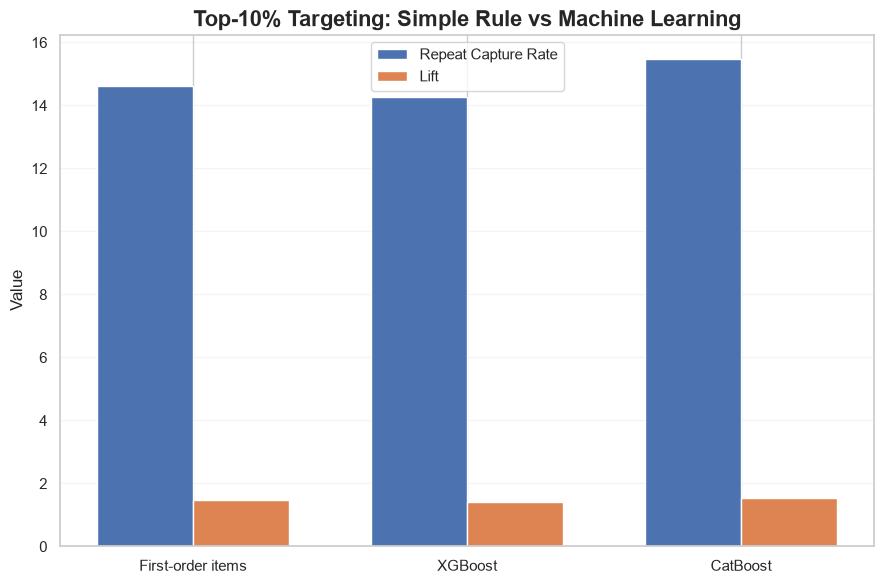

In [35]:
# ============================================================
# CELL 37 — BASELINE VS ML AT TOP-K
# ============================================================

baseline_ml = pd.DataFrame({
    "Method": [
        "First-order items",
        "XGBoost",
        "CatBoost"
    ],
    "Top_10_Capture": [
        14.609,
        14.261,
        15.478
    ],
    "Top_10_Lift": [
        1.461,
        1.426,
        1.548
    ]
})

x = np.arange(len(baseline_ml))
width = 0.35

plt.figure(figsize=(9, 6))

plt.bar(
    x - width / 2,
    baseline_ml["Top_10_Capture"],
    width,
    label="Repeat Capture Rate"
)

plt.bar(
    x + width / 2,
    baseline_ml["Top_10_Lift"],
    width,
    label="Lift"
)

plt.xticks(
    x,
    baseline_ml["Method"]
)

plt.ylabel("Value")
plt.title(
    "Top-10% Targeting: Simple Rule vs Machine Learning",
    fontsize=16,
    fontweight="bold"
)

plt.legend()
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

## Is Machine Learning Actually Better Than a Simple Behavioral Rule?

An important finding is that a sophisticated ML model does not
automatically outperform a simple behavioral heuristic.

At the Top-10% targeting level:

| Method | Repeat Capture | Lift |
|---|---:|---:|
| First-order items | **14.61%** | **1.461×** |
| XGBoost | 14.26% | 1.426× |
| CatBoost | **15.48%** | **1.548×** |

The simple **first-order item count** rule performs almost as well as
the machine-learning models.

CatBoost provides the strongest result, but its improvement over the
simple rule is relatively modest:

\[
1.548 - 1.461 = 0.087
\]

Therefore, the value of ML should not be judged only by whether it
produces a statistically better score.

A production decision should also consider:

- model complexity,
- interpretability,
- maintenance cost,
- scoring infrastructure,
- monitoring requirements,
- and incremental business value.

### Product decision

A practical rollout could begin with the simple first-order item-count
rule as a transparent benchmark.

CatBoost should be preferred when the additional **0.087× lift** or
other operational advantages justify the added complexity.

This leads to an important product principle:

> **The best model is not necessarily the most sophisticated model.
> It is the simplest approach that delivers sufficient incremental
> business value.**

## Final ML Recommendation

The model comparison produces three different winners depending on the
objective.

### Best accuracy

**AdaBoost — 96.92%**

However, this result is not useful for retention because it completely
missed the repeat class:

- Recall = **0%**
- F1 = **0**
- PR-AUC = **0.0332**

Therefore, AdaBoost is rejected for the retention use case.

### Best F1-score

**XGBoost — 0.0734**

XGBoost provides the strongest balance between precision and recall
among the tested classification models.

### Best ranking performance

**CatBoost**

- ROC-AUC = **0.5770**
- PR-AUC = **0.0432**
- Top-10% capture = **15.48%**
- Top-10% lift = **1.548×**

Because the intended application is customer prioritization rather than
definitive binary classification, **CatBoost is selected as the primary
ranking model**.

XGBoost remains a strong alternative when classification-oriented
performance is preferred.

The simple first-order item-count rule remains an important benchmark
because its Top-10% lift of **1.461×** is close to CatBoost's **1.548×**.

# 5. From Analysis to Action

Across the project, the analysis moved through four progressively
stronger questions:

### 1. Who are our customers?

The data audit established the structure, quality, and reliability of
the Olist dataset and resolved the customer identity needed for
customer-level analysis.

### 2. Which customers are valuable?

LTV analysis showed that customer value is highly skewed, with a
relatively small proportion of customers contributing disproportionately
to historical revenue.

This established the importance of distinguishing customer value rather
than treating every customer identically.

### 3. Where is the retention opportunity?

The checkout and incentive analyses showed that:

- Repeat purchasing is relatively uncommon.
- First-order behavior contains useful signals about future behavior.
- Higher first-order spending does not automatically imply greater
  repeat-purchase potential.
- High-value one-time customers represent an especially interesting
  retention opportunity.
- Incentives may be economically attractive under certain conversion
  assumptions, but historical data cannot establish causality.

### 4. Can we prioritize customers?

The ML analysis demonstrated that first-order behavioral information can
be used to rank customers for retention campaigns.

CatBoost achieved:

- PR-AUC = **0.0432**
- ROC-AUC = **0.5770**
- Top-10% capture = **15.48%**
- Top-10% lift = **1.548×**

However, the predictive signal remains weak in absolute terms.

Therefore, the appropriate product is not a system that claims:

> "This customer will definitely repeat."

Instead, it is a system that says:

> **"These customers are relatively more promising targets for
> retention activity."**

# 6. Proposed Customer Retention Strategy

The evidence supports a targeted rather than blanket retention strategy.

## Step 1 — Identify eligible customers

Focus on customers who:

- have completed an initial purchase,
- have not yet made another purchase,
- and satisfy the business-defined eligibility criteria.

## Step 2 — Estimate customer value

Use historical LTV and first-order economics to distinguish between
high-value and lower-value opportunities.

High-value one-time customers receive greater strategic attention
because a successful conversion can have greater economic value.

## Step 3 — Prioritize customers

Use the selected ranking model to score eligible customers.

**Primary model:** CatBoost

**Benchmark:** First-order item count

The business can then select a Top-K segment according to available
retention budget.

For example, targeting the Top 10% with CatBoost captured:

- **15.48% of all repeat customers**
- with **1.548× lift over random targeting**

## Step 4 — Select an intervention

Potential interventions could include:

- targeted discount,
- free shipping,
- personalized recommendation,
- limited-time incentive,
- or other low-cost retention mechanisms.

The intervention should not automatically be applied to every customer.

## Step 5 — Validate causally

Run a randomized A/B test:

**Control:** no incentive

**Treatment:** selected incentive

Measure the difference in repeat-purchase conversion.

## Step 6 — Evaluate economics

The final decision should combine:

- incremental conversion,
- incremental revenue,
- incentive cost,
- incremental profit,
- and ROI.

## Step 7 — Scale only if validated

If the treatment produces statistically significant and economically
meaningful incremental retention, gradually expand the campaign.

If not, revise the intervention rather than simply increasing the
target population.

This creates a closed-loop system:

**Score → Target → Intervene → Experiment → Measure → Improve**

# 7. Core Product Insight

The central finding of this project is not that one particular machine
learning model can perfectly predict repeat purchases.

It cannot.

The repeat class represents only **3.08%** of the modelling population,
and the predictive metrics remain relatively weak.

The stronger finding is that the available first-order information is
good enough to support **targeted prioritization**.

The project therefore combines three layers of evidence:

### Behavioral evidence

First-order characteristics differ between repeat and one-time
customers.

### Predictive evidence

ML models can rank customers somewhat better than random selection.

### Experimental evidence

A/B testing is required to determine whether a retention intervention
actually causes additional purchases.

These layers should not be confused.

**Statistical association → prediction → causal validation**

Each answers a different business question.

The resulting system is therefore best understood as a:

> **Customer Retention Prioritization Framework**

rather than a definitive repeat-purchase prediction engine.

In [37]:
# ============================================================
# CELL 43 — PROJECT EVIDENCE SCORECARD
# ============================================================

evidence_scorecard = pd.DataFrame({
    "Area": [
        "Customer Base",
        "Repeat Purchase",
        "LTV",
        "High-Value Segmentation",
        "Incentive Economics",
        "ML Ranking",
        "Top-K Targeting",
        "Simple Baseline"
    ],
    "Key Metric": [
        "Customers analyzed",
        "Repeat-customer rate",
        "Median historical LTV",
        "High-value threshold",
        "Reference incentive",
        "CatBoost PR-AUC",
        "CatBoost Top-10% lift",
        "Item-count Top-10% lift"
    ],
    "Value": [
        "95,420",
        "3.08%",
        f"R$ {customer_profile['historical_ltv'].median():,.2f}",
        "R$250",
        "R$25",
        "0.0432",
        "1.548×",
        "1.461×"
    ],
    "Interpretation": [
        "Customer-level LTV population",
        "Repeat purchasing is highly imbalanced",
        "Half of customers have historical LTV below this value",
        "Used to identify higher-value customers",
        "Illustrative experimental scenario",
        "Best PR-AUC among tested models",
        "Strongest ML targeting result",
        "Simple behavioral rule performs surprisingly well"
    ]
})

display(evidence_scorecard)

,Area,Key Metric,Value,Interpretation
0,Customer Base,Customers analyzed,"95,420",Customer-level LTV population
1,Repeat Purchase,Repeat-customer rate,3.08%,Repeat purchasing is highly imbalanced
2,LTV,Median historical LTV,R$ 89.90,Half of customers have historical LTV below th...
3,High-Value Segmentation,High-value threshold,R$250,Used to identify higher-value customers
4,Incentive Economics,Reference incentive,R$25,Illustrative experimental scenario
5,ML Ranking,CatBoost PR-AUC,0.0432,Best PR-AUC among tested models
6,Top-K Targeting,CatBoost Top-10% lift,1.548×,Strongest ML targeting result
7,Simple Baseline,Item-count Top-10% lift,1.461×,Simple behavioral rule performs surprisingly well


## What the Evidence Tells Us

The project's strongest quantitative findings can be summarized as
follows:

- The customer-level dataset contains **95,420 customers**.
- Only **3.08%** of the modeling population are repeat customers.
- Customer value is highly skewed, making LTV-based segmentation useful.
- High-value one-time customers represent a potentially attractive
  retention opportunity.
- A hypothetical **R$25 incentive** was used to demonstrate the
  economics of different conversion scenarios.
- The incentive analysis is a scenario model, not causal evidence.
- CatBoost achieved the strongest PR-AUC at **0.0432**.
- At the Top-10% targeting level, CatBoost captured **15.48%** of
  repeat customers.
- This corresponds to **1.548× lift** over random targeting.
- A simple first-order item-count rule achieved **1.461× lift**, showing
  that complex ML provides only a modest incremental improvement.

The overall evidence therefore supports **targeted retention
prioritization**, but does not support claiming highly accurate
individual-level repeat prediction.

# 8. Final Business Recommendations

## 1. Do not target the entire customer base

The repeat rate is only **3.08%**, making blanket retention campaigns
inefficient.

Prioritize customers using value and behavioral signals.

## 2. Prioritize high-value one-time customers

These customers combine demonstrated economic value with an absence of
repeat behavior, making them a natural retention opportunity.

## 3. Use ranking rather than hard classification

The models are better suited to prioritizing customers than making
absolute yes/no predictions.

CatBoost is the recommended primary ranking model.

## 4. Keep the simple baseline

The first-order item-count rule achieved **1.461× lift** at Top-10%,
close to CatBoost's **1.548×**.

It should therefore remain a production benchmark and potentially a
fallback strategy where model complexity is not justified.

## 5. Treat incentives as experiments

Do not assume that an incentive will create incremental purchases simply
because the scenario economics look attractive.

Use randomized A/B testing to establish causal impact.

## 6. Optimize for incremental profit, not conversion alone

A successful campaign must generate enough incremental value to offset:

- incentive cost,
- campaign cost,
- operational cost,
- and any margin reduction.

## 7. Monitor model performance after deployment

If the ranking system is deployed, monitor:

- PR-AUC,
- Top-K capture,
- lift,
- repeat conversion,
- customer mix,
- and incremental campaign ROI.

Model performance should be reassessed as customer behavior changes.

# 9. Final Conclusion

This project investigated customer retention from multiple perspectives,
moving from data quality and customer economics to behavioral analysis,
incentive design, statistical evidence, and machine-learning-based
prioritization.

The analysis produced several important findings.

### Customer economics

Customer value is highly uneven. Historical LTV therefore provides a
useful basis for distinguishing high-value customers from lower-value
customers.

This supports a targeted retention strategy rather than treating the
entire customer base uniformly.

### Retention behavior

Repeat purchasing is relatively rare, with repeat customers representing
only **3.08%** of the modeling population.

First-order behavior contains statistically significant information
about future repeat purchasing, but the predictive relationship is
relatively weak.

Importantly, higher first-order spending does not automatically imply
greater repeat-purchase potential.

### Incentive strategy

High-value one-time customers represent an attractive potential
retention segment.

Scenario analysis demonstrates that incentives can appear economically
attractive under reasonable conversion assumptions.

However, these scenarios are not causal evidence.

The actual incremental effect of an incentive must be established through
randomized experimentation.

### Machine learning

Multiple models were evaluated, including:

- Logistic Regression
- Random Forest
- XGBoost
- LightGBM
- CatBoost
- AdaBoost

CatBoost produced the strongest PR-AUC (**0.0432**) and ROC-AUC
(**0.5770**).

At the Top-10% targeting level, it captured **15.48%** of repeat
customers, corresponding to **1.548× lift** over random targeting.

XGBoost achieved the highest F1-score (**0.0734**).

However, the results do not support describing the system as a highly
accurate individual-level predictor.

The strongest use case is **customer prioritization**.

### Final strategic recommendation

The recommended approach is:

**Identify → Segment → Rank → Target → Experiment → Measure → Improve**

The business should:

1. Identify eligible one-time customers.
2. Segment them using customer value and behavioral information.
3. Rank customers using CatBoost or a simpler benchmark where appropriate.
4. Target a budget-defined Top-K segment.
5. Test retention incentives through randomized A/B experiments.
6. Measure incremental conversion and economics.
7. Scale only interventions that demonstrate statistically credible and
   economically meaningful improvement.

The ultimate objective is not to predict customer behavior perfectly.

It is to make **better retention decisions with limited budget and
imperfect information**.

# 10. Limitations

The conclusions of this project should be interpreted within several
important limitations.

### 1. Observational data

The underlying Olist dataset is observational.

Relationships identified through historical data should therefore not be
interpreted as causal effects.

### 2. Historical LTV is not predictive LTV

Historical LTV describes value that has already been realized.

It should not be interpreted as the amount a customer will necessarily
spend in the future.

### 3. Strong class imbalance

Repeat customers represent only **3.08%** of the modeling population.

This makes accuracy misleading and contributes to low absolute precision.

### 4. Weak predictive signal

The ML models provide useful ranking improvement but relatively modest
predictive performance.

CatBoost's PR-AUC of **0.0432** is only modestly above the approximate
3.08% prevalence baseline.

Therefore, model outputs should be interpreted as relative propensity
scores rather than certainty.

### 5. Incentive assumptions

The incentive economics rely on assumed conversion rates and estimated
customer value.

Actual incremental revenue and profit can only be established through
experimentation.

### 6. Revenue is not profit

Revenue-based analysis does not fully account for:

- product margins,
- fulfillment costs,
- shipping costs,
- operational expenses,
- discount cannibalization,
- and other campaign costs.

Therefore, final production decisions should use incremental profit
rather than revenue alone.

### 7. Historical dataset

Customer behavior can change over time.

A model trained on historical Olist transactions may experience
performance degradation when applied to a different customer population
or future environment.

### 8. Top-K performance is budget-dependent

The optimal targeting percentage depends on:

- campaign capacity,
- incentive budget,
- customer contact limits,
- expected incremental value,
- and operational constraints.

There is no universally optimal Top-K threshold.

### 9. Experimental validation remains necessary

The project identifies promising retention opportunities, but the final
causal question remains:

> **Does targeted intervention actually create additional profitable
> repeat purchases?**

That question requires controlled experimentation.

# 11. What Would I Build Next?

The current project establishes the analytical foundation for a customer-retention decision system. A production-grade version could extend the work in several directions.

### 1. Uplift Modeling

Instead of predicting:

> "Who is likely to repeat?"

build a model that predicts:

> **"Who is more likely to repeat BECAUSE of the intervention?"**

This would distinguish customers who naturally repeat from customers whose behavior can actually be changed by an incentive. This is potentially more valuable than standard propensity modeling.

### 2. Time-to-Event Modeling

Instead of predicting only whether a customer repeats, estimate:

> **When is the customer likely to make the next purchase?**

Survival analysis and time-to-event models could support better campaign timing.

### 3. Incentive Optimization

Different customers may respond differently to:

- discount size
- free shipping
- product recommendations
- loyalty rewards
- or other interventions

Future experiments could estimate the optimal intervention for each customer segment.

### 4. Profit-Based Optimization

Replace revenue-based optimization with contribution-margin-based optimization. The decision objective could become:


Expected Incremental Profit =
    Incremental Revenue
    − Incentive Cost
    − Incremental Operating Cost


### 5. Production Deployment

A production system could periodically:

1. Ingest new customer transactions
2. Generate customer features
3. Score eligible customers
4. Rank customers
5. Select the campaign population
6. Assign treatment/control groups
7. Record outcomes
8. Retrain and monitor the model

### 6. Continuous Experimentation

The retention system should become a feedback loop:


Prediction → Intervention → Experiment → Outcome → Learning → Improved Prediction


This would transform the project from a static analytical exercise into a continuously improving retention decision system.

---

# Final Takeaway

The project does not conclude that machine learning can perfectly predict repeat purchases. Instead, it demonstrates something more useful:

> **Customer behavior, customer value, statistical analysis, machine learning, and experimentation can be combined to make retention decisions more targeted, measurable, and economically disciplined.**

The next level is not simply a more complex model. It is a system that learns **which customers to target, which intervention to use, and whether that intervention actually creates incremental profitable behavior.**
